In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
 data = pd.read_csv("CarPrice_Assignment.csv")

In [3]:
# Drop unnecessary columns
data = data.drop(columns=["car_ID", "CarName"])

In [4]:
# Converting categorical variables using OneHotEncoding
categorical_cols = ["fueltype", "aspiration", "doornumber", "carbody", "drivewheel", "enginelocation", "enginetype", "cylindernumber", "fuelsystem"]
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

In [5]:
# Defining input and output features
X = data.drop(columns=["price"])
y = data["price"]

In [6]:
# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Standardizing the numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# Training the Model using Linear Regression
LR = LinearRegression()
LR.fit(X_train, y_train)

# Predictions using Linear Regression
predicted_LR = LR.predict(X_test)


In [9]:
# Evaluating the Linear Regression performnace
mse_lr = mean_squared_error(y_test, predicted_LR)
mae_lr = mean_absolute_error(y_test, predicted_LR)
r2_lr = r2_score(y_test, predicted_LR)


In [10]:
# Building Neural Network Model
NN = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1)
])

NN.compile(optimizer='adam', loss='mse')       # we use this loss because is binary classification.

C:\Users\Mbash\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Training Neural Network
NN.fit(X_train, y_train, epochs=100, batch_size=10, verbose=0)

# Predictions using Neural Network
predicted_NN = NN.predict(X_test).flatten()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


In [22]:
# Evaluating linear Regression
mse_nn = mean_squared_error(y_test, predicted_LR)
mae_nn = mean_absolute_error(y_test, predicted_LR)
r2_nn = r2_score(y_test, predicted_LR)

# Evaluating linear Regression
mse_nn = mean_squared_error(y_test, predicted_NN)
mae_nn = mean_absolute_error(y_test, predicted_NN)
r2_nn = r2_score(y_test, predicted_NN)

In [36]:
# Printing evaluation results
print("Linear Regression:")
print(f"MSE: {mse_lr}, MAE: {mae_lr}, R²: {r2_lr}")
print("\nNeural Network:")
print(f"MSE: {mse_nn}, MAE: {mae_nn}, R²: {r2_nn}")

Linear Regression:
MSE: 8482008.484371936, MAE: 2089.382729204776, R²: 0.8925566700320229

Neural Network:
MSE: 9556951.12158816, MAE: 2193.6726135670733, R²: 0.878940152590444


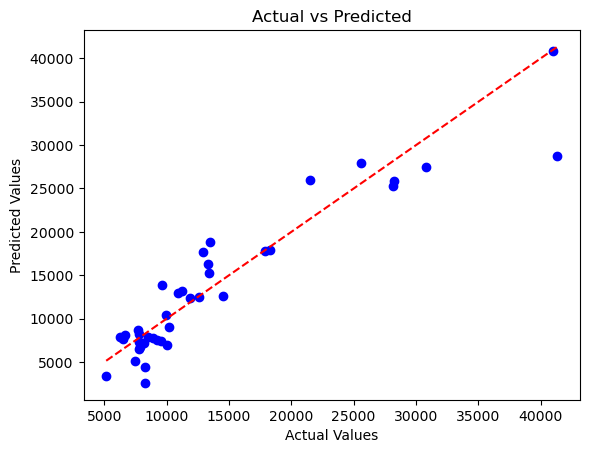

In [38]:
import matplotlib.pyplot as plt
# Scattering plot for actual vs predicted values of the trained model
plt.scatter(y_test, predicted_NN, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.show()

**PROJECT COMMENTS AND CHALLENGES**

**Project Comment**

In this project, I built a car price prediction model using Linear Regression and a Neural Network. The goal was to develop a system that can predict the price of a car based on various features such as enginetype, stroke, cardoor, wheelbase among many bother.

*1. Model Performance*

The R² Score for Linear regresion used is about 89.26% and R² Score 88.57% respectively.

*2. Comparison of Models*
The R² Score accuarcy of Linear regression is much more accurate than the neural network though the accuracy is almost the same, that means the LR performnace is more slightly  better than Neurak network.

**Project Challenges**
1. Handling Date Features
2. Feature Selection & Engineering because some may cause some noise and redundancy
3. Dealing with Outliers & Missing Data
4. Avoiding Overfitting & Underfitting
5. Comparing Model Performance using the recommended evaluation model R² Score, Mean Squared Error (MSE), and Mean Absolute Error (MAE).